$$J = mv_\infty b$$

In com frame, particles have equal and opposite momenta, paramaterized by impact parameter and momentum
$$J = mr^2\dot{\theta}$$

In [ ]:
import numpy as np
#1 is Si, 2 is H
def coll(y, t, b, c):
    x1, x2,y1,y2,vx1,vx2,vy1,vy2 = y
    
    dydt = [vx1,vx2,vy1,vy2,ax1,ax2,ay1,ay2]
    return dydt

$$\frac{df_{Si}(v_3)}{dt} = \int\int  \sigma_{Si-H}(v_3;v_1,v_2) n_H|v_2-v_1|f_{Si}(v_2)f_{H}(v_1)dv_2dv_1$$

Assuming head on collisions only
$$\sigma_{Si-H}(v_3;v_1,v_2) = \delta(v_3-\frac{m_H-m_{Si}}{m_H+m_Si}v_1-\frac{2m_{Si}}{m_H+m_{Si}}v_2)$$

Check H normalization
1.0000000255872437
[ 4.86141234 -1.56122502  4.06929383]


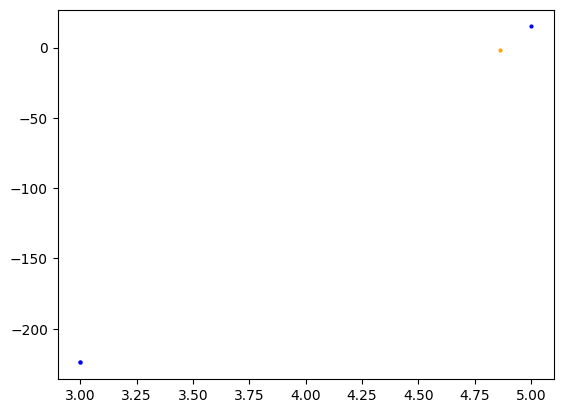

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
vSi = np.linspace(-1e5,1e5,int(1e2))
vH = np.linspace(-1e5,1e5,int(1e2))
probSi = np.zeros((len(vSi),len(vSi),len(vSi)))
probH =  np.zeros((len(vH),len(vH),len(vH)))
NA = 6.022e23
mH = 1.008*0.001/NA
mSi = 28.0855*0.001/NA

T=15000
pi = 3.1415926
kb = 1.38e-23

total=0
dvH = vH[1]-vH[0]

for i in range(len(vH)):
    for j in range(len(vH)):
        for k in range(len(vH)):
            probH[i,j,k] = np.exp(-mH*((vH[i]**2)+(vH[j]**2)+(vH[k]**2))/(2*kb*T))*(mH/(2*pi*kb*T))**(1.5)

dt = 1e-10
def elastic(vH,vSi):
    vHn = (mH-mSi)*vH/(mH+mSi) + 2*mSi*vSi/(mH+mSi)
    vSin = 2*mH*vH/(mH+mSi) +vSi*(mSi-mH)/(mH+mSi)
    return vHn,vSin

#vsi*(mH+mSi) = 2mH*vH + (mSi-mH)vSi
def invcoll(v1,v3):#find hydrogen initial velocity such that v1 goes to v2
    (v3-(mH-mSi)*v1/(mH+mSi))*(mH+mSi)/(2*mSi)
    return v2



print("Check H normalization")
print(np.sum(probH)*(dvH**3))

v1 = np.array([3,-224,5])
v2 =np.array([5,15,4])
dump,v3 = elastic(v1,v2)
print(v3)
plt.scatter(v1[0],v1[1],v1[2],color="blue")
plt.scatter(v2[0],v2[1],v2[2],color="blue")
plt.scatter(v3[0],v3[1],v3[2],color="orange")
plt.show()
